# Stock Price Predictor

This notebook trains a model to predict future stock prices using historical data and technical indicators.


In [ ]:
# ============================================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================================
# NumPy: For numerical operations and array manipulations
import numpy as np

# Pandas: For data manipulation and analysis (DataFrames, Series)
import pandas as pd

# yfinance: For downloading stock market data from Yahoo Finance
import yfinance as yf

# Matplotlib: For creating plots and visualizations
import matplotlib.pyplot as plt

# Seaborn: For statistical data visualization (enhanced matplotlib)
import seaborn as sns

# Scikit-learn: Machine learning library
from sklearn.preprocessing import StandardScaler  # For feature scaling
from sklearn.ensemble import GradientBoostingRegressor  # Our chosen model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  # Evaluation metrics

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


## 1. Data Loading and Preprocessing


In [77]:
# ============================================================================
# STEP 1: LOAD STOCK DATA
# ============================================================================
# Define the stock symbol to analyze
# Format: "SYMBOL.EXCHANGE" (e.g., "ANGELONE.NS" for NSE, "AAPL" for NASDAQ)
symbol = "ANGELONE.NS"

# Period: How much historical data to download
# Options: "1d", "5d", "1mo", "3mo", "6mo", "1y", "2y", "5y", "10y", "ytd", "max"
period = "5y"  # 5 years of historical data

# Interval: Data frequency
# Options: "1m", "2m", "5m", "15m", "30m", "60m", "90m", "1h", "1d", "5d", "1wk", "1mo", "3mo"
interval = "1d"  # Daily interval (one data point per trading day)

print(f"Downloading data for {symbol}...")
# Download historical stock data from Yahoo Finance
# auto_adjust=True: Automatically adjusts prices for splits and dividends
df = yf.download(symbol, period=period, interval=interval, auto_adjust=True)

# yfinance sometimes returns multi-indexed columns, we need to flatten them
# Example: ('Close', 'AAPL') becomes just 'Close'
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Convert all column names to lowercase for consistency
# This makes the code more robust (case-insensitive)
df = df.rename(columns=str.lower)

# Display basic information about the downloaded data
print(f"\nData shape: {df.shape}")  # (number of rows, number of columns)
print(f"\nFirst few rows:")
print(df.head())  # Show first 5 rows
print(f"\nData info:")
print(df.info())  # Show data types and non-null counts


[*********************100%***********************]  1 of 1 completed


Data shape: (1237, 5)

First few rows:
Price            close        high         low        open  volume
Date                                                              
2020-11-10  295.924042  312.216326  291.546328  306.800604  721991
2020-11-11  299.715088  305.807775  291.862307  295.788711  505739
2020-11-12  305.130768  310.050059  294.795782  300.572547  517305
2020-11-13  317.902863  328.644038  302.603438  302.603438  915610
2020-11-14  317.541840  320.430236  312.848230  316.819754  149447

Data info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1237 entries, 2020-11-10 to 2025-11-10
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   close   1237 non-null   float64
 1   high    1237 non-null   float64
 2   low     1237 non-null   float64
 3   open    1237 non-null   float64
 4   volume  1237 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.0 KB
None


## 2. Feature Engineering


In [78]:
# ============================================================================
# STEP 2: FEATURE ENGINEERING - CREATE TECHNICAL INDICATORS
# ============================================================================
# Feature engineering is the process of creating new features from raw data
# that help the model make better predictions.

# CRITICAL: Only use PAST data - no future data leakage!
# Data leakage occurs when we use information that wouldn't be available
# at prediction time, making the model appear better than it actually is.

def create_features(df):
    """
    Create technical indicators and features for stock price prediction.
    
    IMPORTANT: All features use only historical (past) data to avoid data leakage.
    This ensures the model can be used in real-time trading scenarios.
    
    Parameters:
    - df: DataFrame with stock price data (must have 'close', 'high', 'low', 'volume' columns)
    
    Returns:
    - DataFrame with original data plus new technical indicator features
    """
    # Create a copy to avoid modifying the original dataframe
    df = df.copy()
    
    # ------------------------------------------------------------------------
    # MOVING AVERAGES (Simple Moving Averages - SMA)
    # ------------------------------------------------------------------------
    # Moving averages smooth out price data to identify trends
    # They use only past data (rolling window looks backward)
    df['sma_5'] = df['close'].rolling(window=5).mean()    # 5-day average
    df['sma_10'] = df['close'].rolling(window=10).mean()   # 10-day average
    df['sma_20'] = df['close'].rolling(window=20).mean()   # 20-day average (monthly)
    df['sma_50'] = df['close'].rolling(window=50).mean()   # 50-day average
    df['sma_200'] = df['close'].rolling(window=200).mean()  # 200-day average (long-term trend)
    
    # ------------------------------------------------------------------------
    # EXPONENTIAL MOVING AVERAGES (EMA)
    # ------------------------------------------------------------------------
    # EMA gives more weight to recent prices, making it more responsive to changes
    # ewm = exponentially weighted moving average
    df['ema_12'] = df['close'].ewm(span=12, adjust=False).mean()  # 12-day EMA
    df['ema_26'] = df['close'].ewm(span=26, adjust=False).mean()  # 26-day EMA
    
    # ------------------------------------------------------------------------
    # MACD (Moving Average Convergence Divergence) SIGNAL
    # ------------------------------------------------------------------------
    # MACD is a momentum indicator that shows the relationship between two EMAs
    # We only keep the signal line (removed macd and macd_hist to reduce overfitting)
    df['macd'] = df['ema_12'] - df['ema_26']  # Difference between EMAs
    df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()  # Signal line (9-day EMA of MACD)
    
    # ------------------------------------------------------------------------
    # BOLLINGER BANDS
    # ------------------------------------------------------------------------
    # Bollinger Bands show volatility - when bands are wide, volatility is high
    # Middle band = moving average, upper/lower = middle ± 2 standard deviations
    df['bb_middle'] = df['close'].rolling(window=20).mean()  # Middle band (20-day SMA)
    bb_std = df['close'].rolling(window=20).std()  # Standard deviation
    df['bb_upper'] = df['bb_middle'] + (bb_std * 2)  # Upper band
    df['bb_lower'] = df['bb_middle'] - (bb_std * 2)  # Lower band
    df['bb_width'] = df['bb_upper'] - df['bb_lower']  # Band width (volatility measure)
    
    # ------------------------------------------------------------------------
    # PRICE CHANGE INDICATORS
    # ------------------------------------------------------------------------
    # pct_change() calculates percentage change from previous day (uses only past data)
    df['price_change'] = df['close'].pct_change()  # Daily percentage change
    
    # High/low ratio: Intraday volatility (known at end of day, so safe to use)
    df['high_low_ratio'] = df['high'] / df['low']
    
    # ------------------------------------------------------------------------
    # VOLUME INDICATORS
    # ------------------------------------------------------------------------
    # Volume helps confirm price movements (high volume = stronger signal)
    df['volume_sma'] = df['volume'].rolling(window=20).mean()  # Average volume
    df['volume_ratio'] = df['volume'] / df['volume_sma']  # Current volume vs average
    
    # ------------------------------------------------------------------------
    # LAGGED FEATURES (Historical Price and Volume)
    # ------------------------------------------------------------------------
    # Lagged features use past values to capture momentum and patterns
    # shift(lag) moves data backward by 'lag' days (only past data)
    for lag in [1, 2, 3, 5, 10]:
        df[f'close_lag_{lag}'] = df['close'].shift(lag)  # Price 'lag' days ago
        if lag != 5:  # Removed volume_lag_5 to reduce overfitting
            df[f'volume_lag_{lag}'] = df['volume'].shift(lag)  # Volume 'lag' days ago
    
    # ------------------------------------------------------------------------
    # TIME-BASED FEATURES
    # ------------------------------------------------------------------------
    # These capture seasonal patterns (e.g., stocks may behave differently on Mondays)
    # These are known at prediction time, so safe to use
    df['day_of_week'] = df.index.dayofweek  # 0=Monday, 6=Sunday
    df['month'] = df.index.month  # 1-12
    df['quarter'] = df.index.quarter  # 1-4
    
    return df

# Apply feature engineering to create all technical indicators
df_features = create_features(df)
print(f"Features created. New shape: {df_features.shape}")
print(f"\nFeature columns: {list(df_features.columns)}")


Features created. New shape: (1237, 34)

Feature columns: ['close', 'high', 'low', 'open', 'volume', 'sma_5', 'sma_10', 'sma_20', 'sma_50', 'sma_200', 'ema_12', 'ema_26', 'macd', 'macd_signal', 'bb_middle', 'bb_upper', 'bb_lower', 'bb_width', 'price_change', 'high_low_ratio', 'volume_sma', 'volume_ratio', 'close_lag_1', 'volume_lag_1', 'close_lag_2', 'volume_lag_2', 'close_lag_3', 'volume_lag_3', 'close_lag_5', 'close_lag_10', 'volume_lag_10', 'day_of_week', 'month', 'quarter']


## 3. Prepare Data for Training


In [79]:
# ============================================================================
# STEP 3: PREPARE DATA FOR TRAINING
# ============================================================================
# In this step, we prepare the data for machine learning:
# 1. Define what we want to predict (target variable)
# 2. Select which features to use for prediction
# 3. Clean the data (remove missing values)

# ----------------------------------------------------------------------------
# DEFINE TARGET VARIABLE (What we want to predict)
# ----------------------------------------------------------------------------
# We want to predict the NEXT day's closing price
# shift(-1) moves the close price forward by 1 day
# So for each row, 'target' contains tomorrow's price
df_features['target'] = df_features['close'].shift(-1)

# ----------------------------------------------------------------------------
# CLEAN DATA (Remove rows with missing values)
# ----------------------------------------------------------------------------
# Technical indicators need historical data to calculate
# For example, SMA_200 needs 200 days of history
# This creates NaN (Not a Number) values at the beginning
# We drop these rows since we can't use them for training
df_clean = df_features.dropna()

# ----------------------------------------------------------------------------
# SELECT FEATURES (Choose which columns to use for prediction)
# ----------------------------------------------------------------------------
# We exclude:
# - 'target': This is what we're predicting, not a feature
# - 'open', 'high', 'low', 'close', 'volume': Raw price data (we use derived features instead)
# - 'close_open_ratio', 'macd', 'rsi', 'volume_lag_5', 'macd_hist': Removed to prevent overfitting
excluded_features = ['target', 'open', 'high', 'low', 'close', 'volume', 
                     'close_open_ratio', 'macd', 'rsi', 'volume_lag_5', 'macd_hist']

# Select only numeric features (float64, int64) that aren't excluded
feature_cols = [col for col in df_clean.columns 
                if col not in excluded_features
                and df_clean[col].dtype in ['float64', 'int64']]

# ----------------------------------------------------------------------------
# SEPARATE FEATURES (X) AND TARGET (y)
# ----------------------------------------------------------------------------
# X: Features (input) - what the model uses to make predictions
# y: Target (output) - what we want to predict
X = df_clean[feature_cols]
y = df_clean['target']

print(f"Features: {len(feature_cols)}")
print(f"\nSelected features:\n{feature_cols}")
print(f"\nData shape after cleaning: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nRemoved features to prevent overfitting: close_open_ratio, macd, rsi, volume_lag_5, macd_hist")


Features: 25

Selected features:
['sma_5', 'sma_10', 'sma_20', 'sma_50', 'sma_200', 'ema_12', 'ema_26', 'macd_signal', 'bb_middle', 'bb_upper', 'bb_lower', 'bb_width', 'price_change', 'high_low_ratio', 'volume_sma', 'volume_ratio', 'close_lag_1', 'volume_lag_1', 'close_lag_2', 'volume_lag_2', 'close_lag_3', 'volume_lag_3', 'close_lag_5', 'close_lag_10', 'volume_lag_10']

Data shape after cleaning: (1037, 25)
Target shape: (1037,)

Removed features to prevent overfitting: close_open_ratio, macd, rsi, volume_lag_5, macd_hist


## 4. Train-Test Split


In [80]:
# ============================================================================
# STEP 4: TRAIN-TEST SPLIT AND FEATURE SCALING
# ============================================================================

# ----------------------------------------------------------------------------
# SPLIT DATA INTO TRAINING AND TESTING SETS
# ----------------------------------------------------------------------------
# For time series data, we MUST use chronological split (not random)
# Random split would cause data leakage (future data in training set)
# We use 80% for training, 20% for testing
split_idx = int(len(X) * 0.8)

# Training set: First 80% of data (chronologically)
X_train = X.iloc[:split_idx]  # Features for training
y_train = y.iloc[:split_idx]  # Target values for training

# Test set: Last 20% of data (chronologically)
X_test = X.iloc[split_idx:]   # Features for testing
y_test = y.iloc[split_idx:]    # Target values for testing

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

# ----------------------------------------------------------------------------
# FEATURE SCALING (Normalization)
# ----------------------------------------------------------------------------
# Machine learning models work better when features are on similar scales
# Example: SMA_200 might be 2000, while day_of_week is 0-6
# StandardScaler transforms features to have mean=0 and std=1

# Create scaler object
scaler = StandardScaler()

# Fit scaler on training data (learn mean and std from training set only)
# Then transform both training and test sets
X_train_scaled = scaler.fit_transform(X_train)  # Fit on train, transform train
X_test_scaled = scaler.transform(X_test)       # Transform test (using train's mean/std)

# IMPORTANT: We fit on training data only to avoid data leakage
# If we fit on entire dataset, test set information leaks into training

print("\nFeatures scaled successfully.")


Training set size: 829
Test set size: 208

Features scaled successfully.


## 5. Model Training


In [81]:
# ============================================================================
# STEP 5: TRAIN GRADIENT BOOSTING MODEL
# ============================================================================
# Gradient Boosting is an ensemble method that combines multiple weak learners
# (decision trees) to create a strong predictive model.
# It builds trees sequentially, where each new tree corrects errors of previous trees.

print("Training Gradient Boosting Regressor...")

# Create and configure the Gradient Boosting model
gb_model = GradientBoostingRegressor(
    n_estimators=100,        # Number of trees (more trees = better but slower)
    learning_rate=0.05,      # How much each tree contributes (lower = more conservative)
    max_depth=3,             # Maximum depth of each tree (prevents overfitting)
    min_samples_split=10,    # Minimum samples needed to split a node (regularization)
    min_samples_leaf=5,      # Minimum samples in a leaf node (regularization)
    subsample=0.8,           # Use 80% of data for each tree (prevents overfitting)
    random_state=42          # For reproducibility (same results every run)
)

# Train the model on training data
# The model learns the relationship between features (X_train_scaled) and target (y_train)
gb_model.fit(X_train_scaled, y_train)

# Make predictions on both training and test sets
# Training predictions: To check if model learned the patterns
# Test predictions: To evaluate how well model generalizes to new data
y_train_pred = gb_model.predict(X_train_scaled)
y_test_pred = gb_model.predict(X_test_scaled)

print("Gradient Boosting training completed.")


Training Gradient Boosting Regressor...
Gradient Boosting training completed.


In [82]:
## 6. Model Evaluation


## 7. Feature Importance


In [83]:
# ============================================================================
# STEP 6: EVALUATE MODEL PERFORMANCE
# ============================================================================
# We evaluate the model using several metrics to understand its performance

def evaluate_model(y_true, y_pred, dataset_name):
    """
    Calculate and display model evaluation metrics.
    
    Parameters:
    - y_true: Actual values (ground truth)
    - y_pred: Predicted values from the model
    - dataset_name: Name of dataset (e.g., "Train" or "Test")
    
    Returns:
    - Dictionary with all metrics
    """
    # RMSE (Root Mean Squared Error): Average prediction error in price units
    # Lower is better. Measures how far predictions are from actual values.
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # MAE (Mean Absolute Error): Average absolute prediction error
    # Lower is better. Easier to interpret than RMSE (not squared).
    mae = mean_absolute_error(y_true, y_pred)
    
    # R² Score (Coefficient of Determination): How well model explains variance
    # Range: -∞ to 1. Higher is better. 1 = perfect, 0 = no better than mean
    r2 = r2_score(y_true, y_pred)
    
    # MAPE (Mean Absolute Percentage Error): Average error as percentage
    # Lower is better. Useful for understanding relative error.
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    # Print results
    print(f"\n{dataset_name} Set Metrics:")
    print(f"  RMSE: {rmse:.2f}")      # Error in price units
    print(f"  MAE: {mae:.2f}")        # Average absolute error
    print(f"  R² Score: {r2:.4f}")    # Model fit quality (0-1)
    print(f"  MAPE: {mape:.2f}%")    # Average percentage error
    
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

# Evaluate on training set (how well model learned)
print("=" * 60)
print("TRAINING SET EVALUATION")
print("=" * 60)
train_metrics = evaluate_model(y_train, y_train_pred, "Training")

# Evaluate on test set (how well model generalizes)
print("\n" + "=" * 60)
print("TEST SET EVALUATION")
print("=" * 60)
test_metrics = evaluate_model(y_test, y_test_pred, "Test")

# Check for overfitting
# Overfitting: Model performs well on training but poorly on test
# Good model: Similar performance on both sets
print("\n" + "=" * 60)
print("OVERFITTING CHECK")
print("=" * 60)
r2_gap = train_metrics['R2'] - test_metrics['R2']
print(f"Train R²: {train_metrics['R2']:.4f}")
print(f"Test R²:  {test_metrics['R2']:.4f}")
print(f"R² Gap:   {r2_gap:.4f}")
if r2_gap < 0.1:
    print("✓ Good: Low overfitting (gap < 0.1)")
else:
    print("⚠ Warning: Possible overfitting (gap >= 0.1)")


TRAINING SET EVALUATION

Training Set Metrics:
  RMSE: 51.56
  MAE: 35.67
  R² Score: 0.9951
  MAPE: 1.97%

TEST SET EVALUATION

Test Set Metrics:
  RMSE: 79.52
  MAE: 62.52
  R² Score: 0.9248
  MAPE: 2.59%

OVERFITTING CHECK
Train R²: 0.9951
Test R²:  0.9248
R² Gap:   0.0703
✓ Good: Low overfitting (gap < 0.1)


## 8. Visualization


Top 10 Most Important Features:
        feature  importance
3        sma_50    0.328968
16  close_lag_1    0.194691
6        ema_26    0.099108
0         sma_5    0.098244
9      bb_upper    0.077338
4       sma_200    0.062682
5        ema_12    0.054767
2        sma_20    0.043340
20  close_lag_3    0.016797
22  close_lag_5    0.011671


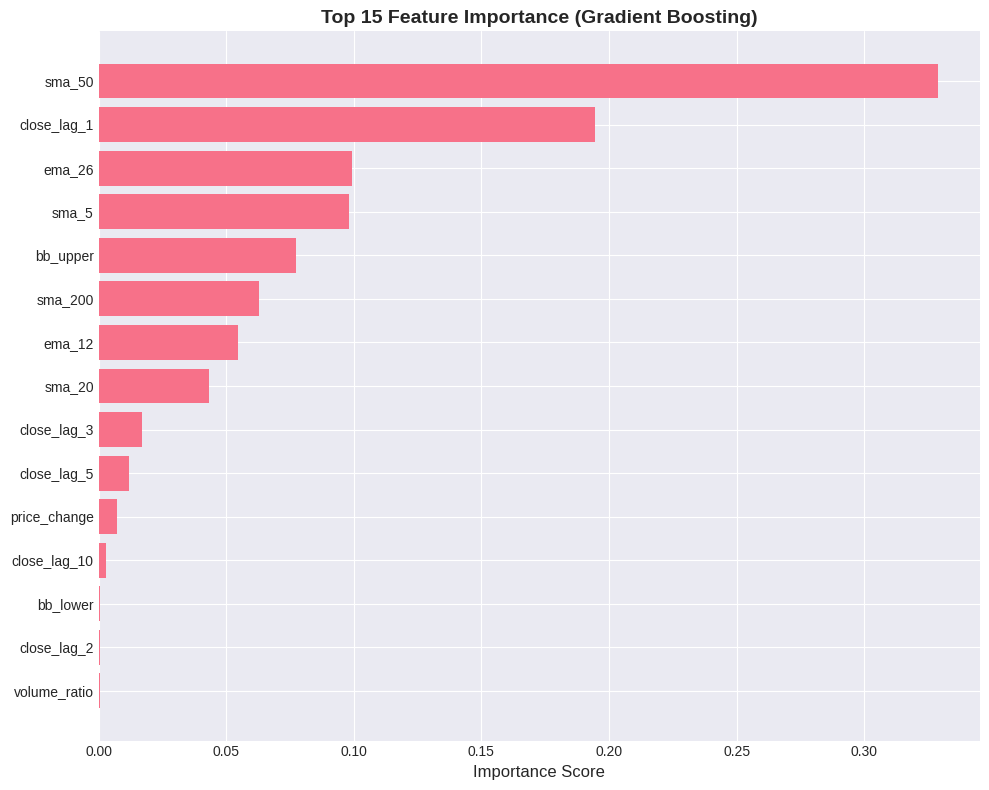

In [84]:
# ============================================================================
# STEP 7: FEATURE IMPORTANCE
# ============================================================================
# Feature importance shows which features the model considers most important
# for making predictions. This helps us understand what drives price movements.

# Get feature importance from the trained model
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': gb_model.feature_importances_  # Importance scores from Gradient Boosting
}).sort_values('importance', ascending=False)  # Sort by importance (highest first)

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

# Visualize feature importance
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)  # Show top 15 features
plt.barh(range(len(top_features)), top_features['importance'].values)
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 15 Feature Importance (Gradient Boosting)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Highest importance at top
plt.tight_layout()
plt.show()


## 9. Backtesting


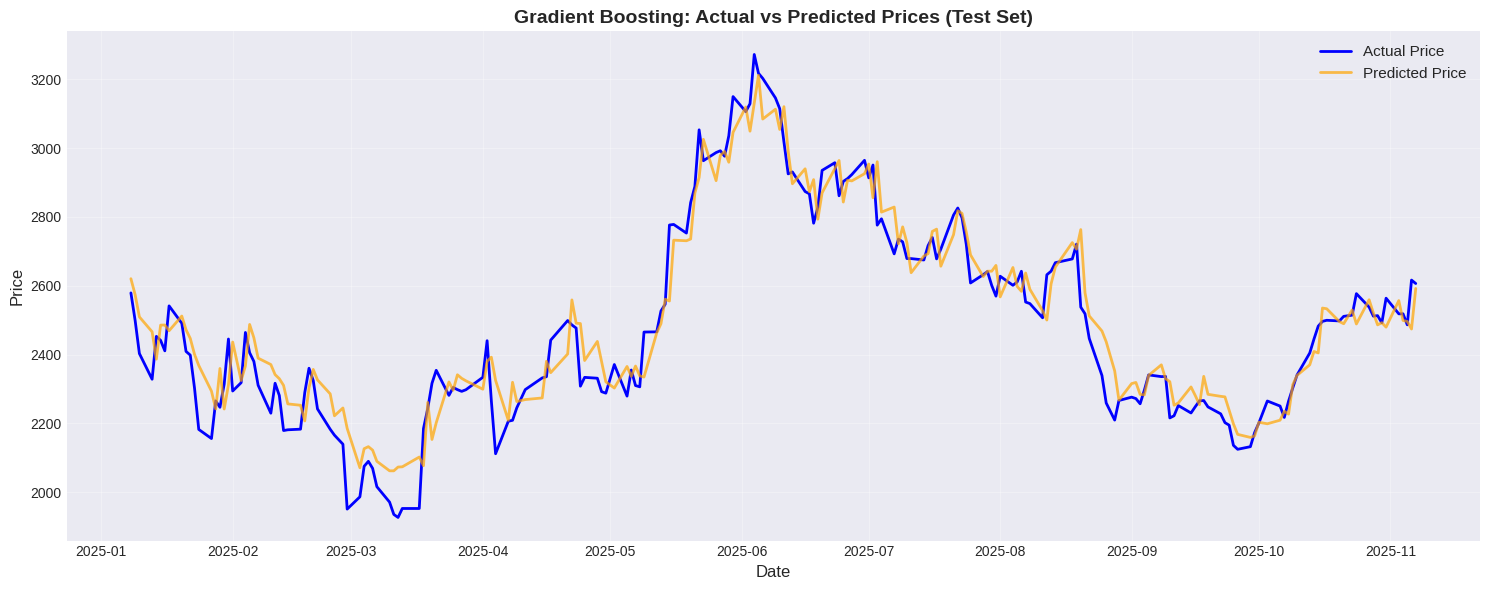

In [85]:
# ============================================================================
# STEP 8: VISUALIZE PREDICTIONS
# ============================================================================
# Plot actual vs predicted prices to visually assess model performance

fig, ax = plt.subplots(figsize=(15, 6))

# Plot actual prices (ground truth)
ax.plot(y_test.index, y_test.values, label='Actual Price', linewidth=2, color='blue')

# Plot predicted prices
ax.plot(y_test.index, y_test_pred, label='Predicted Price', linewidth=2, 
        color='orange', alpha=0.7)

ax.set_title('Gradient Boosting: Actual vs Predicted Prices (Test Set)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 10. Save Model


BACKTESTING RESULTS - SMA-BASED STRATEGY

Strategy Rules:
  BUY:  close < sma_20 < sma_50 < sma_200 (only if not in position)
  SELL: close > sma_20 > sma_50 > sma_200 (only if in position)
  HOLD: All other conditions

Position Management:
  - Can only hold ONE position at a time
  - Must sell before buying again
  - Returns calculated from entry to exit price

📊 CLASSIFICATION METRICS:
  Precision:  0.5000 (50.00%)
  Recall:     0.0096 (0.96%)
  Accuracy:   0.5000 (50.00%)
  F1 Score:   0.0189

📈 CONFUSION MATRIX:
  True Negatives (TN):  103  |  False Positives (FP):   1
  False Negatives (FN): 103  |  True Positives (TP):     1

💰 TRADING PERFORMANCE:
  Number of Buy Signals:       2
  Number of Sell Signals:      1
  Completed Trades:            1
  Total Return:                 58.35%
  Average Return per Trade:     29.18%
  Win Rate:                   100.00%
  Average Win:                  29.18%
  Average Loss:                  0.00%
  Profit Factor:                58.35


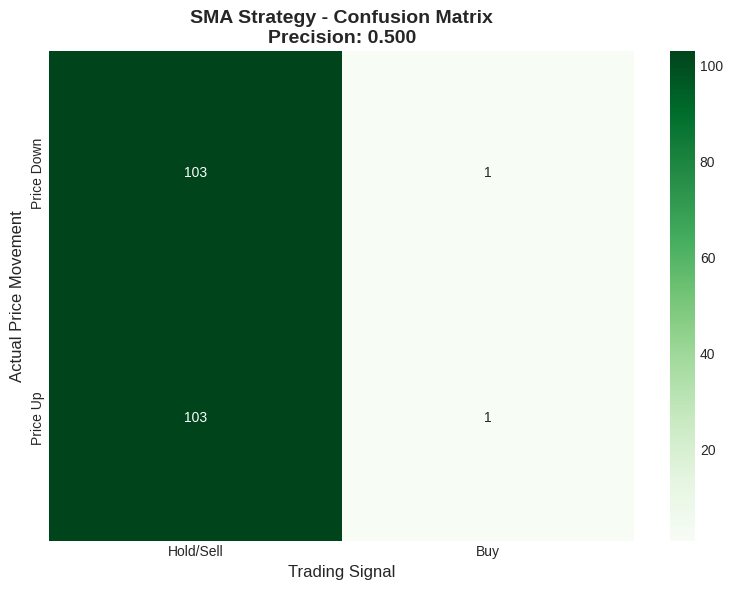

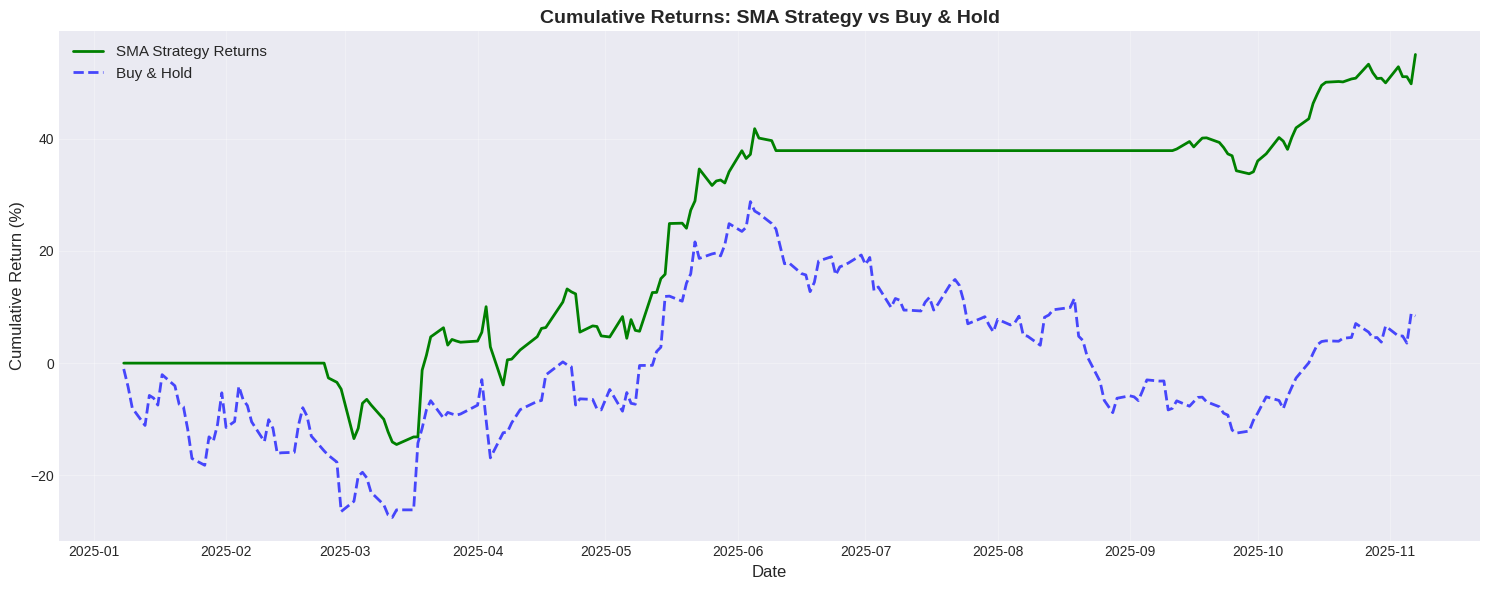

In [ ]:
# ============================================================================
# STEP 9: BACKTESTING - EVALUATE TRADING STRATEGY
# ============================================================================
# Backtesting simulates how the strategy would perform in real trading
# Strategy based on Moving Average (MA) alignment:
# - BUY: When price is below all SMAs and SMAs are in descending order (bearish to bullish reversal)
# - SELL: When price is above all SMAs and SMAs are in ascending order (bullish to bearish reversal)
#
# We import the backtesting functions from a separate module for better organization

# Import backtesting functions from the separate module
# The backtest_strategy.py file is in the same directory (algosPOC folder)
from backtest_strategy import backtest_strategy, print_backtest_results, plot_backtest_results

# ------------------------------------------------------------------------
# PREPARE DATA FOR BACKTESTING
# ------------------------------------------------------------------------
# Get test set indices to extract corresponding SMA values
test_indices = X_test.index

# Extract required data for backtesting:
# - Current closing prices (at prediction time)
# - SMA values (20, 50, 200-day) for the same dates
current_prices_test = df_clean.loc[test_indices, 'close'].values
sma_20_test = df_clean.loc[test_indices, 'sma_20'].values
sma_50_test = df_clean.loc[test_indices, 'sma_50'].values
sma_200_test = df_clean.loc[test_indices, 'sma_200'].values

# Run backtest with SMA-based strategy
backtest_results = backtest_strategy(
    y_actual=y_test.values,
    current_prices=current_prices_test,
    sma_20=sma_20_test,
    sma_50=sma_50_test,
    sma_200=sma_200_test
)

# Display results using the imported function
print_backtest_results(backtest_results)

# Create visualizations using the imported function
plot_backtest_results(backtest_results, y_test.index)


## 11. Future Predictions


In [87]:
# ============================================================================
# STEP 10: PREDICT FUTURE PRICES
# ============================================================================
# This function predicts prices for the next N days
# Note: For multi-day predictions, we use the previous day's prediction
# to calculate features for the next day (iterative prediction)

def predict_future(model, scaler, df_features, feature_cols, n_days=5):
    """
    Predict future stock prices for the next N days.
    
    How it works:
    1. Use the latest available data to predict tomorrow's price
    2. Use that prediction to update features and predict the day after
    3. Repeat for N days
    
    Parameters:
    - model: Trained Gradient Boosting model
    - scaler: Fitted StandardScaler (for feature normalization)
    - df_features: DataFrame with all historical features
    - feature_cols: List of feature column names to use
    - n_days: Number of days to predict into the future
    
    Returns:
    - List of predicted prices for next N days
    """
    predictions = []
    current_df = df_features.copy()  # Work with a copy to avoid modifying original
    
    for i in range(n_days):
        # Get the latest row of features (most recent data)
        latest_features = current_df[feature_cols].iloc[-1:].values
        
        # Scale features using the same scaler from training
        latest_features_scaled = scaler.transform(latest_features)
        
        # Predict next day's price
        next_price = model.predict(latest_features_scaled)[0]
        predictions.append(next_price)
        
        # Create a new row with predicted price for next iteration
        # We copy the last row and update the close price
        new_row = current_df.iloc[-1:].copy()
        new_row['close'] = next_price
        new_row.index = [new_row.index[0] + pd.Timedelta(days=1)]  # Next day's date
        
        # Add the new row to dataframe
        current_df = pd.concat([current_df, new_row])
        
        # Recalculate all features with the new price
        # This ensures features for next prediction are based on predicted price
        current_df = create_features(current_df)
    
    return predictions

# Predict next 5 days
n_future_days = 5
future_predictions = predict_future(gb_model, scaler, df_features, feature_cols, n_future_days)

print(f"\nPredictions for next {n_future_days} days:")
for i, pred in enumerate(future_predictions, 1):
    print(f"  Day {i}: ₹{pred:.2f}")



Predictions for next 5 days:
  Day 1: ₹2595.99
  Day 2: ₹2565.90
  Day 3: ₹2565.11
  Day 4: ₹2568.94
  Day 5: ₹2572.29


In [ ]:
# ============================================================================
# STEP 11: SAVE MODEL FOR FUTURE USE
# ============================================================================
# Save the trained model, scaler, and feature list so we can use them later
# without retraining

import joblib
import os
import json

# Create models directory if it doesn't exist
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

# Save the trained Gradient Boosting model
# This allows us to load and use the model later without retraining
joblib.dump(gb_model, f'{models_dir}/gb_model_{symbol}.pkl')

# Save the scaler (important: we need the same scaling for predictions)
# The scaler contains the mean and std used during training
joblib.dump(scaler, f'{models_dir}/scaler_{symbol}.pkl')

# Save the list of feature columns
# This ensures we use the same features in the same order when making predictions
with open(f'{models_dir}/feature_cols_{symbol}.json', 'w') as f:
    json.dump(feature_cols, f)

print(f"✓ Model saved to {models_dir}/")
print(f"  - Gradient Boosting Model: gb_model_{symbol}.pkl")
print(f"  - Scaler: scaler_{symbol}.pkl")
print(f"  - Feature Columns: feature_cols_{symbol}.json")
